#In this practical session you will
- Train RNNs as sentence encoders
- Use RNNs for sentiment analysis (binary classification)
- Train RNNs as decoders
- Use RNNs for automatic text generation

In [1]:
!pip install googledrivedownloader

# Part 1: RNN Text Classification: Predict the sentiment of IMDB movie reviews

![imdb](https://static.amazon.jobs/teams/53/images/IMDb_Header_Page.jpg)

## Imports

In [2]:
# Download stopwords
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [3]:
import random
import re
from collections import Counter
from functools import partial
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from nltk import wordpunct_tokenize
from tqdm import tqdm, tqdm_notebook
from sklearn.metrics import classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.dataset import random_split
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

from IPython.core.display import display, HTML
from googledrivedownloader import download_file_from_google_drive

# Make plots look pretty
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']
plt.style.use('ggplot')

tqdm.pandas()

## CUDA

In order to perform deep learning on a GPU (so that everything runs super quick!), CUDA has to be installed and configured. Fortunately, Google Colab already has this set up, but if you want to try this on your own GPU, you can [install CUDA from here](https://developer.nvidia.com/cuda-downloads). M
You need to activate the GPU in Collab.

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Download the data

This is a dataset of positive and negative IMDB reviews. We can download the data from a public Google Drive folder.

In [5]:
DATA_PATH = 'data/imdb_reviews.csv'
if not Path(DATA_PATH).is_file():
    download_file_from_google_drive(
        file_id='1zfM5E6HvKIe7f3rEt1V2gBpw5QOSSKQz',
        dest_path=DATA_PATH,
    )

## Preprocess the text

In [ ]:
def remove_rare_words(tokens, common_tokens, max_len):
    return [token if token in common_tokens
            else '<UNK>' for token in tokens][-max_len:]


def tokenize(text, stop_words):
    text = re.sub(r'[^\w\s]', '', text)
    text = text.lower()
    tokens = wordpunct_tokenize(text)
    tokens = [token for token in tokens if token not in stop_words]
    return tokens


class ImdbSentimentDataset(Dataset):
    def __init__(self, data_path, max_vocab, max_len):
        df = pd.read_csv(data_path)

        # Clean and tokenize
        stop_words = set(stopwords.words('english'))
        df['tokens'] = df.review.progress_apply(
            partial(tokenize, stop_words=stop_words),
        )

        # Replace rare words with <UNK>
        all_tokens = [sublst for lst in df.tokens.tolist() for sublst in lst]
        common_tokens = set(list(zip(
            *Counter(all_tokens).most_common(max_vocab)))[0])
        df.loc[:, 'tokens'] = df.tokens.progress_apply(
            partial(
                remove_rare_words,
                common_tokens=common_tokens,
                max_len=max_len,
            ),
        )

        # Remove sequences with only <UNK>
        df = df[df.tokens.progress_apply(
            lambda tokens: any(token != '<UNK>' for token in tokens),
        )]

        vocab = sorted({
            sublst for lst in df.tokens.tolist() for sublst in lst
        })
        self.token2idx = {token: idx for idx, token in enumerate(vocab)}

        # Add a padding idx
        self.token2idx['<PAD>'] = max(self.token2idx.values()) + 1

        self.idx2token = {idx: token for token, idx in self.token2idx.items()}

        df['indexed_tokens'] = df.tokens.apply(
            lambda tokens: [self.token2idx[token] for token in tokens],
        )
        self.text = df.review.tolist()
        self.sequences = df.indexed_tokens.tolist()
        self.targets = df.label.tolist()

    def __getitem__(self, i):
        return self.sequences[i], self.targets[i],  self.text[i]

    def __len__(self):
        return len(self.sequences)

In [ ]:
# How many of the most common vocab words to keep
# Uncommon words get replaced with unknown token <UNK>
max_vocab = 1000  #@param {type:"integer"}

# How many tokens long each sequence will be cut to
# Shorter sequences will get the padding token <PAD>
max_len = 220  #@param {type:"slider", min:16, max:512, step:2}

dataset = ImdbSentimentDataset(DATA_PATH, max_vocab, max_len)

100%|██████████| 62155/62155 [00:00<00:00, 569829.43it/s]


## Split into training, validation, and test sets

- **Training**: data the model learns from
- **Validation**: data to evaluate with for hyperparameter tuning (make sure the model doesn't overfit!)
- **Testing**: data to evaluate the final performance of the model

In [ ]:
def split_train_valid_test(corpus, valid_ratio=0.1, test_ratio=0.1):
    """Split dataset into train, validation, and test."""
    test_length = int(len(corpus) * test_ratio)
    valid_length = int(len(corpus) * valid_ratio)
    train_length = len(corpus) - valid_length - test_length
    return random_split(
        corpus, lengths=[train_length, valid_length, test_length],
    )

In [ ]:
valid_ratio = 0.05  #@param {type:"slider", min:0.01, max:0.3, step:0.01}
test_ratio = 0.06  #@param {type:"slider", min:0.01, max:0.3, step:0.01}

train_dataset, valid_dataset, test_dataset = split_train_valid_test(
    dataset, valid_ratio=valid_ratio, test_ratio=test_ratio)
len(train_dataset), len(valid_dataset), len(test_dataset)

(55318, 3107, 3729)

## Create the dataloader

In [ ]:
def collate(batch):
    inputs = [item[0] for item in batch]
    target = torch.LongTensor([item[1] for item in batch])
    text = [item[2] for item in batch]
    return inputs, target, text

# Powers of two are preferred for optimal usage on the GPU
batch_size = 512  #@param {type:"integer"}

train_loader = DataLoader(train_dataset, batch_size=batch_size, collate_fn=collate)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, collate_fn=collate)
test_loader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=collate)

## Reminder on the model architecture

**Standard RNN Structure:**

![RNN](https://miro.medium.com/max/700/1*o-Cq5U8-tfa1_ve2Pf3nfg.gif)

**LSTM cell**

- Why is LSTM able to preserve long term dependency nicely?

![LSTMcell](https://miro.medium.com/max/700/1*0f8r3Vd-i4ueYND1CUrhMA.png)

**LSTM**

![LSTM](https://miro.medium.com/max/700/1*n-IgHZM5baBUjq0T7RYDBw.gif)



## Tuning the batch
We need to pad the different sequences so that the batches are square matrices

In [ ]:
def pad_sequences(sequences, padding_val=0, pad_left=False):
    """Pad a list of sequences to the same length with a padding_val."""
    sequence_length = max(len(sequence) for sequence in sequences)
    if not pad_left:
        return [
            sequence + (sequence_length - len(sequence)) * [padding_val]
            for sequence in sequences
        ]
    return [
        (sequence_length - len(sequence)) * [padding_val] + sequence
        for sequence in sequences
    ]


## The RNNs

We are going to create the RNN networks


### First, the LSTM ###

In [ ]:
class LSTM_RNNClassifier(nn.Module):
    def __init__(self, output_size, hidden_size, vocab_size, padding_idx,
                 device, dropout_probability=0.3, bidirectional=False, n_layers=1,
                 embedding_dimension=50, batch_size=32):
        super(LSTM_RNNClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.batch_size = batch_size
        self.n_layers = n_layers
        self.dropout_probability = dropout_probability
        self.device = device
        self.padding_idx = padding_idx

        # We need to multiply some layers by two if the model is bidirectional
        self.input_size_factor = 2 if bidirectional else 1

        self.embedding = nn.Embedding(vocab_size, embedding_dimension)

        self.rnn = nn.LSTM(
            embedding_dimension,
            self.hidden_size,
            self.n_layers,
            bidirectional=bidirectional,
        )

        self.fc1 = nn.Linear(
            self.hidden_size * self.input_size_factor,
            16,
        )
        self.fc2 = nn.Linear(
            16,
            self.output_size,
        )


    def init_hidden(self):
        """Set initial hidden states."""
        h0 = torch.randn(
            self.n_layers * self.input_size_factor,
            self.batch_size,
            self.hidden_size,
        )
        c0 = torch.randn(
            self.n_layers * self.input_size_factor,
            self.batch_size,
            self.hidden_size,
        )

        h0 = h0.to(self.device)
        c0 = c0.to(self.device)

        return h0, c0

    def apply_rnn(self, embedding_out, lengths):
        packed = pack_padded_sequence(
            embedding_out,
            lengths,
            batch_first=True,
        )
        activations, _ = self.rnn(packed, self.init_hidden())
        activations, _ = pad_packed_sequence(activations, batch_first=True)

        indices = (lengths - 1).view(-1, 1).expand(
            activations.size(0), activations.size(2),
        ).unsqueeze(1)
        indices = indices.to(self.device)

        activations = activations.gather(1, indices).squeeze(1)
        return activations

    def forward(self, inputs, return_activations=False):
        batch_size = len(inputs)

        # This makes the model not break for the last batch that might be less
        # than batch_size in size
        if batch_size != self.batch_size:
            self.batch_size = batch_size

        lengths = torch.LongTensor([len(x) for x in inputs])
        lengths, permutation_indices = lengths.sort(0, descending=True)

        # Pad sequences so that they are all the same length
        padded_inputs = pad_sequences(inputs, padding_val=self.padding_idx)
        inputs = torch.LongTensor(padded_inputs)

        # Sort inputs
        inputs = inputs[permutation_indices].to(self.device)

        # Get embeddings
        embedding_out = self.embedding(inputs)

        activations = self.apply_rnn(embedding_out, lengths)

        x = F.dropout(torch.relu(self.fc1(activations)), 0.05)
        x = self.fc2(x)
        out = torch.sigmoid(x)

        # Put the output back in correct order
        permutation_index_pairs = list(zip(
            permutation_indices.tolist(),
            list(range(len(permutation_indices))),
        ))
        reordered_indices = [
            pair[1] for pair
            in sorted(permutation_index_pairs, key=lambda pair: pair[0])
        ]

        if return_activations:
            return out[reordered_indices], x[reordered_indices]

        return out[reordered_indices]

https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html

### Second, the standard RNN ###

It's almost the same code as above, just remember that the RNN doesn't have a cell state!

In [ ]:
#Homework!

https://pytorch.org/docs/stable/generated/torch.nn.RNN.html

You can easily replace the RNN by a GRU.

https://pytorch.org/docs/stable/generated/torch.nn.GRU.html

## Train the model

In [ ]:
def train_epoch(model, optimizer, scheduler, train_loader):
    model.train()
    total_loss = total = 0
    progress_bar = tqdm_notebook(train_loader, desc='Training', leave=False)
    for inputs, target, text in progress_bar:
        target = target.to(device)

        # Clean old gradients
        optimizer.zero_grad()

        # Forwards pass
        output = model(inputs)

        # Calculate how wrong the model is
        loss = criterion(output, target)

        # Perform gradient descent, backwards pass
        loss.backward()

        # Take a step in the right direction
        optimizer.step()
        scheduler.step()

        # Record metrics
        total_loss += loss.item()
        total += len(target)

    return total_loss / total


def validate_epoch(model, valid_loader):
    model.eval()
    total_loss = total = 0
    with torch.no_grad():
        progress_bar = tqdm_notebook(valid_loader, desc='Validating', leave=False)
        for inputs, target, text in progress_bar:
            target = target.to(device)

            # Forwards pass
            output = model(inputs)

            # Calculate how wrong the model is
            loss = criterion(output, target)

            # Record metrics
            total_loss += loss.item()
            total += len(target)

    return total_loss / total

In [ ]:
dropout_probability = 0.2  #@param {type:"slider", min:0.0, max:0.8, step:0.1}
n_rnn_layers = 1  #@param {type:"integer"}
embedding_dimension = 128  #@param {type:"integer"}
hidden_size = 64  #@param {type:"integer"}
is_bidirectional = False  #@param ["False", "True"] {type:"raw"}
max_epochs = 10  #@param {type:"integer"}
learning_rate = 0.001  #@param {type:"number"}

model = LSTM_RNNClassifier(
    output_size=2,  # two classes: positive vs. negative
    hidden_size=hidden_size,
    embedding_dimension=embedding_dimension,
    vocab_size=len(dataset.token2idx),
    padding_idx=dataset.token2idx['<PAD>'],
    dropout_probability=dropout_probability,
    bidirectional=is_bidirectional,
    n_layers=n_rnn_layers,
    device=device,
    batch_size=batch_size,
)
model = model.to(device)
model

LSTM_RNNClassifier(
  (embedding): Embedding(1002, 128)
  (rnn): LSTM(128, 64)
  (fc1): Linear(in_features=64, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=2, bias=True)
)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=learning_rate,
)
scheduler = CosineAnnealingLR(optimizer, 1)

https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html

In [ ]:
n_epochs = 0
train_losses, valid_losses = [], []
for _ in range(max_epochs):
    train_loss = train_epoch(model, optimizer, scheduler, train_loader)
    valid_loss = validate_epoch(model, valid_loader)

    tqdm.write(
        f'epoch #{n_epochs + 1:3d}\ttrain_loss: {train_loss:.2e}'
        f'\tvalid_loss: {valid_loss:.2e}\n',
    )

    # Early stopping if the current valid_loss is greater than the last three valid losses
    if len(valid_losses) > 2 and all(valid_loss >= loss
                                     for loss in valid_losses[-3:]):
        print('Stopping early')
        break

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    n_epochs += 1

<ipython-input-13-b858bc31747f>:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  progress_bar = tqdm_notebook(train_loader, desc='Training', leave=False)


Training:   0%|          | 0/109 [00:00<?, ?it/s]

<ipython-input-13-b858bc31747f>:35: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  progress_bar = tqdm_notebook(valid_loader, desc='Validating', leave=False)


Validating:   0%|          | 0/7 [00:00<?, ?it/s]

epoch #  1	train_loss: 1.35e-03	valid_loss: 1.55e-03



...

Validating:   0%|          | 0/7 [00:00<?, ?it/s]

epoch #  9	train_loss: 8.96e-04	valid_loss: 1.07e-03



Training:   0%|          | 0/109 [00:00<?, ?it/s]

Validating:   0%|          | 0/7 [00:00<?, ?it/s]

epoch # 10	train_loss: 8.83e-04	valid_loss: 1.03e-03



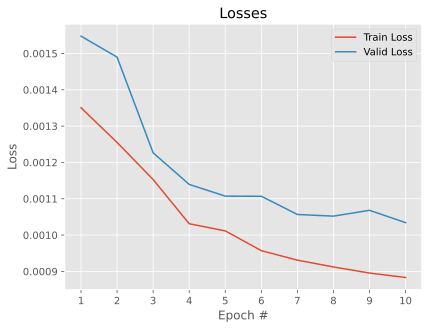

In [ ]:
epoch_ticks = range(1, n_epochs + 1)
plt.plot(epoch_ticks, train_losses)
plt.plot(epoch_ticks, valid_losses)
plt.legend(['Train Loss', 'Valid Loss'])
plt.title('Losses')
plt.xlabel('Epoch #')
plt.ylabel('Loss')
plt.xticks(epoch_ticks)
plt.show()

## Predictions

In [ ]:
model.eval()
test_accuracy = n_examples = 0
y_true, y_pred = [], []
with torch.no_grad():
    for inputs, target, text in tqdm_notebook(test_loader, leave=False):
        target = target.to(device)

        _, logits = model(inputs, return_activations=True)

        logits = logits.detach().cpu().numpy()
        predictions = np.argmax(logits, axis=1)
        target = target.cpu().numpy()

        y_true.extend(predictions)
        y_pred.extend(target)

print(classification_report(y_true, y_pred))

<ipython-input-18-52705c3918d6>:5: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for inputs, target, text in tqdm_notebook(test_loader, leave=False):


  0%|          | 0/8 [00:00<?, ?it/s]

              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1988
           1       0.81      0.86      0.83      1741

    accuracy                           0.84      3729
   macro avg       0.84      0.84      0.84      3729
weighted avg       0.84      0.84      0.84      3729



Precision:- Accuracy of positive predictions

Precision = TP/(TP + FP)

Recall:- Fraction of positives that were correctly identified.

Recall = TP/(TP+FN)

The F1 score is a weighted harmonic mean of precision and recall such that the best score is 1.0 and the worst is 0.0

If you want to (roughly) compare models, you should compare the weighted average of F1-score

In [ ]:
flatten = lambda x: [sublst for lst in x for sublst in lst]
inputs_lst, target_lst, text_lst = zip(*test_loader)
inputs_lst, target_lst, text_lst = map(flatten, [inputs_lst, target_lst, text_lst])
test_examples = list(zip(inputs_lst, target_lst, text_lst))

def print_random_prediction(n=10):
    to_emoji = lambda x: '😄' if x else '😡'
    model.eval()
    rows = []
    for _ in range(n):
        with torch.no_grad():
            inputs, target, text = random.choice(test_examples)
            target = target.item()

            _, logits = model([inputs], return_activations=True)
            logits = logits.detach().cpu().numpy()
            prediction = np.argmax(logits, axis=1)[0]

            predicted = to_emoji(prediction)
            actual = to_emoji(target)

            row = f"""
            <tr>
            <td>{text}&nbsp;</td>
            <td>{predicted}&nbsp;</td>
            <td>{actual}&nbsp;</td>
            </tr>
            """
            rows.append(row)

    rows_joined = '\n'.join(rows)
    table = f"""
<table>
<tbody>
<tr>
<td><b>Review</b>&nbsp;</td>
<td><b>Predicted</b>&nbsp;</td>
<td><b>Actual</b>&nbsp;</td>
</tr>
{rows_joined}
</tbody>
</table>
"""
    display(HTML(table))

In [ ]:
print_random_prediction(n=5)

Review,Predicted,Actual
"As much as I dislike saying 'me too' in response to other comments - it's completely true that the first 30 minutes of this film have nothing whatsoever to do with the endless dirge that comprises the following 90.Having been banned somewhere doesn't make a film watchable. Just because it doesn't resemble a Hollywood product does not make it credible.Worse yet, in addition to no discernible plot (other than there are lots of muddy places in Russia and many people, even very old women, drink lots of vodka) a number of visuals are so unnecessarily nauseating I'm in to my second package of Rolaids.As for spoilers - well, the film is so devoid of any narrative thread I couldn't write one if I tried.Don't waste your time or money, and don't confuse this with good Russian cinema.",😡,😡
"Usually, any film with Sylvester Stallone is usually going to suck ass. Rambo: First Blood Part II was no exception to this. The only movies that Sylvester Stallone were in that were good were Rocky and First Blood. This film is extreamly unrealistic, and boring. It has action, but not very good action. I didn't enjoy watching it, and I would never ever watch this again. No wonder why it won the Razzie Award for Worst Picture. I would give this a 3/10, the only reason why it got the 3 was because it had somewhat good action, but not good enough.",😡,😡
"Friday Night With Jonathan Ross must have those in charge of Ross rubbing their sweaty little palms together. They know the BBC lacks imagination when it comes to talk shows so when they have Jonathan Ross at their disposal they are quite settled to just sit back and let a half wit command this primetime slot.Ross Spends most of the show grooming his ego and smiling about how much the BBC is paying him. The show is a complete copy of many US Chat Shows - Leno, Letterman, Conan O Brian, the list goes on - but he and his team have clearly seen what works on the masses can also be done for the dumb masses in the UK also.The unfortunate situation - he has no competition? Parkinson has gone by the reality is he was never really up to much except grooming a celebs ego. Can't we have someone funnier and slicker on British Screens instead of Jonathan Ross? Once Ross has built up his ego enough he will then proceed to the very boring concept of the stiff celebrities in the green room - so trying to get on with each other. If an A-Lister is present (which is so often the case these days - as there are no other chat shows they can turn to - to promote their latest movie) - he will spend the next hour either flirting with them or trying to be their best friend in the Universe. Sqeamish when he had Ringo Starr on - a man that cares nothing for licking arse - Ross genuinely was begging for his mobile phone number (as common policy on this show is for Jonathan Ross to get everyones number so he can be seen in the right company when not working). Of course Ringo said it how it is - and simply said no I don't like you - dead pan serious.Ross needs to be axed from all Awards and TV shows - the masses will get over it.",😡,😡
"Jane Porter's former love interest Harry Holt(Neil Hamilton) and his friend Martin (Paul Cavanagh) come to Tarzan's hidden away jungle escarpment searching for the ivory gold mine that is the \Elephant's Graveyard\"" first seen in TARZAN, THE APE MAN...only we soon discover both men have hidden intentions...namely Jane. Will Tarzan stand for that? Not likely (in fact Tarzan won't even stand for any disturbance done to the \""Elephant's Graveyard\"") and knowing this Martin attempts to take Tarzan out of the picture only he later finds himself in a world of trouble later he and his party (including Jane who leaves with them after she believes Tarzan is dead)is captured by a native tribe intent on feeding them to the lions..will Tarzan be will and able enough to get to them in time?This film is adventure filled with loads of scenes involving Tarzan and other facing down wild anim

# Part 2: RNN Text Generation: Generate a movie plot

## Download the data

In [ ]:
!wget --no-check-certificate 'https://docs.google.com/uc?export=download&id=1PakdWMKYNyC5-2G_CSlLtkBsHezFpMHJ' -O plots_text.pickle

--2023-10-01 16:15:01--  https://docs.google.com/uc?export=download&id=1PakdWMKYNyC5-2G_CSlLtkBsHezFpMHJ
Resolving docs.google.com (docs.google.com)... 142.251.12.113, 142.251.12.100, 142.251.12.138, ...
Connecting to docs.google.com (docs.google.com)|142.251.12.113|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://doc-0g-00-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/bpi5datn85tg3tslgpm4rm2v3clho7t9/1696176900000/14172408186104425556/*/1PakdWMKYNyC5-2G_CSlLtkBsHezFpMHJ?e=download&uuid=fbf9c100-4a45-4d00-b920-1087ebd5dc56 [following]
--2023-10-01 16:15:02--  https://doc-0g-00-docs.googleusercontent.com/docs/securesc/ha0ro937gcuc7l7deffksulhg5h7mbp1/bpi5datn85tg3tslgpm4rm2v3clho7t9/1696176900000/14172408186104425556/*/1PakdWMKYNyC5-2G_CSlLtkBsHezFpMHJ?e=download&uuid=fbf9c100-4a45-4d00-b920-1087ebd5dc56
Resolving doc-0g-00-docs.googleusercontent.com (doc-0g-00-docs.googleusercontent.com)... 74.125.68.132, 2404:6800:4

**The CMU movie corpus**

![Genre](https://raw.githubusercontent.com/askmeegs/movies/master/genre_explorer.jpg)


## Imports

In [ ]:
import pickle
import re
import numpy as np
import torch.nn as nn
import torch
import torch.nn.functional as F
import random

## Read the pickle file

In [ ]:
# read pickle file

pickle_in = open("plots_text.pickle","rb")
movie_plots = pickle.load(pickle_in)

# count of movie plot summaries
len(movie_plots)

500

In [ ]:
movie_plots[0]

'barry is a private with the 101st airborne division of the united states army, stationed at fort campbell, kentucky. calpernia works as a showgirl at a transgender revue in nashville, tennessee when the two met in 1999. barry\'s roommate justin fisher  brings barry to the club where she performs. when barry and calpernia begin seeing each other regularly, fisher begins spreading rumors on base about their relationship, which appeared to be a violation of the military\'s "don\'t ask, don\'t tell" policy about discussing the sexual orientation of military personnel. barry faces increasing harassment and pressure, which explode into violence over fourth of july weekend. while calpernia performs in a pageant in nashville, barry is beaten to death in his sleep with a baseball bat by calvin glover, who had been goaded by fisher into committing the crime. the film ends with a discussion of the aftermath.'

In [ ]:
movie_plots = [re.sub("[^a-z ' ]", " ", i) for i in movie_plots]

In [ ]:
movie_plots[0]

"barry is a private with the    st airborne division of the united states army  stationed at fort campbell  kentucky  calpernia works as a showgirl at a transgender revue in nashville  tennessee when the two met in       barry's roommate justin fisher  brings barry to the club where she performs  when barry and calpernia begin seeing each other regularly  fisher begins spreading rumors on base about their relationship  which appeared to be a violation of the military's  don't ask  don't tell  policy about discussing the sexual orientation of military personnel  barry faces increasing harassment and pressure  which explode into violence over fourth of july weekend  while calpernia performs in a pageant in nashville  barry is beaten to death in his sleep with a baseball bat by calvin glover  who had been goaded by fisher into committing the crime  the film ends with a discussion of the aftermath "

## Create a data_loader

In [ ]:
def get_fixed_sequence(text, seq_len = 5):
  sequences = []
  words = text.split()
  if len(words) > seq_len:
    for i in range(seq_len, len(words)):
      seq_list = words[i-seq_len: i]
      sequences.append(" ".join(seq_list))
  else:
    sequences = words
  return sequences

In [ ]:
get_fixed_sequence('good morning this is mr prabhakar this is')

['good morning this is mr',
 'morning this is mr prabhakar',
 'this is mr prabhakar this']

In [ ]:
seqs = [get_fixed_sequence(plot) for plot in movie_plots]

In [ ]:
len(seqs)

500

In [ ]:
seqs = sum(seqs, [])

In [ ]:
len(seqs)

154295

In [ ]:
seqs[0]

'barry is a private with'

In [ ]:
seqs[1]

'is a private with the'

Create the truth

In [ ]:
x = []
y = []
for seq in seqs:
  words = seq.split()
  x.append(" ".join(words[:-1]))
  y.append(" ".join(words[1:]))

In [ ]:
x[0], y[0]

('barry is a private', 'is a private with')

### Create a mapping between word tokens and words

In [ ]:
# create integer-to-token mapping
int2token = {}
cnt = 0

for w in set(" ".join(movie_plots).split()):
  int2token[cnt] = w
  cnt+= 1

# create token-to-integer mapping
token2int = {t: i for i, t in int2token.items()}

token2int["the"], int2token[14271]

(4909, 'valuables')

In [ ]:
# set vocabulary size
vocab_size = len(int2token)
vocab_size

16120

In [ ]:
def get_integer_seq(seq):
  return [token2int[w] for w in seq.split()]

# convert text sequences to integer sequences
x_int = [get_integer_seq(i) for i in x]
y_int = [get_integer_seq(i) for i in y]

# convert lists to numpy arrays
x_int = np.array(x_int)
y_int = np.array(y_int)

In [ ]:
x_int[0]

array([ 4453,  4641, 13647,  6952])

### Define the dataloader

In [ ]:
def get_batches(arr_x, arr_y, batch_size):
  prev = 0
  for n in range(batch_size, arr_x.shape[0], batch_size):
    x = arr_x[prev:n]
    y = arr_y[prev:n]
    prev = n
    yield x,y

## Create the LSTM network

In [ ]:
class WordLSTM(nn.Module):

    def __init__(self, n_hidden=256, n_layers=4, drop_prob=0.3, lr=0.001):
        super().__init__()

        self.drop_prob = drop_prob
        self.n_layers = n_layers
        self.n_hidden = n_hidden
        self.lr = lr

        self.emb_layer = nn.Embedding(vocab_size, 200)

        ## define the LSTM
        self.lstm = nn.LSTM(200, n_hidden, n_layers,
                            dropout=drop_prob, batch_first=True)

        ## define a dropout layer
        self.dropout = nn.Dropout(drop_prob)

        ## define the fully-connected layer
        self.fc = nn.Linear(n_hidden, vocab_size)

    def forward(self, x, hidden):
        ''' Forward pass through the network.
            These inputs are x, and the hidden/cell state `hidden`. '''

        ## pass input through embedding layer
        embedded = self.emb_layer(x)

        ## Get the outputs and the new hidden state from the lstm
        lstm_output, hidden = self.lstm(embedded, hidden)

        ## pass through a dropout layer
        out = self.dropout(lstm_output)

        #out = out.contiguous().view(-1, self.n_hidden)
        out = out.reshape(-1, self.n_hidden)

        ## put "out" through the fully-connected layer
        out = self.fc(out)

        # return the final output and the hidden state
        return out, hidden


    def init_hidden(self, batch_size):
        ''' initializes hidden state '''
        # Create two new tensors with sizes n_layers x batch_size x n_hidden,
        # initialized to zero, for hidden state and cell state of LSTM
        weight = next(self.parameters()).data

        # if GPU is available
        if (torch.cuda.is_available()):
          hidden = (weight.new(self.n_layers, batch_size, self.n_hidden).zero_().cuda(),
                    weight.new(self.n_layers, batch_size, self.n_hidden).zero_().cuda())

        # if GPU is not available
        else:
          hidden = (weight.new(self.n_layers, batch_size, self.n_hidden).zero_(),
                    weight.new(self.n_layers, batch_size, self.n_hidden).zero_())

        return hidden

In [ ]:
# instantiate the model
net = WordLSTM()

# push the model to GPU (avoid it if you are not using the GPU)
if (torch.cuda.is_available()):
  net.cuda()

print(net)


WordLSTM(
  (emb_layer): Embedding(16120, 200)
  (lstm): LSTM(200, 256, num_layers=4, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=16120, bias=True)
)


## Define the training function

In [ ]:
def train(net, epochs=10, batch_size=32, lr=0.001, clip=1, print_every=32):

    # optimizer
    opt = torch.optim.Adam(net.parameters(), lr=lr)

    # loss
    criterion = nn.CrossEntropyLoss()

    # push model to GPU
    net.cuda()

    counter = 0

    net.train()

    for e in range(epochs):

        # initialize hidden state
        h = net.init_hidden(batch_size)

        for x, y in get_batches(x_int, y_int, batch_size):
            counter+= 1

            # convert numpy arrays to PyTorch arrays
            inputs, targets = torch.from_numpy(x), torch.from_numpy(y)

            # push tensors to GPU
            inputs, targets = inputs.cuda(), targets.cuda()

            # detach hidden states
            h = tuple([each.data for each in h])

            # zero accumulated gradients
            net.zero_grad()

            # get the output from the model
            output, h = net(inputs, h)

            # calculate the loss and perform backprop
            loss = criterion(output, targets.view(-1))

            # back-propagate error
            loss.backward()

            # `clip_grad_norm` helps prevent the exploding gradient problem in RNNs / LSTMs.
            nn.utils.clip_grad_norm_(net.parameters(), clip)

            # update weigths
            opt.step()

            if counter % print_every == 0:

              print("Epoch: {}/{}...".format(e+1, epochs),
                    "Step: {}...".format(counter))

## Train the netwok

In [ ]:
train(net, batch_size = 32, epochs=20, print_every=256)

Epoch: 1/20... Step: 256...
Epoch: 1/20... Step: 512...
Epoch: 1/20... Step: 768...
Epoch: 1/20... Step: 1024...
Epoch: 1/20... Step: 1280...
Epoch: 1/20... Step: 1536...
Epoch: 1/20... Step: 1792...
Epoch: 1/20... Step: 2048...
Epoch: 1/20... Step: 2304...
Epoch: 1/20... Step: 2560...
Epoch: 1/20... Step: 2816...
Epoch: 1/20... Step: 3072...
Epoch: 1/20... Step: 3328...
Epoch: 1/20... Step: 3584...
Epoch: 1/20... Step: 3840...
Epoch: 1/20... Step: 4096...
Epoch: 1/20... Step: 4352...
Epoch: 1/20... Step: 4608...
Epoch: 2/20... Step: 4864...
Epoch: 2/20... Step: 5120...
Epoch: 2/20... Step: 5376...
Epoch: 2/20... Step: 5632...
Epoch: 2/20... Step: 5888...
Epoch: 2/20... Step: 6144...
Epoch: 2/20... Step: 6400...
Epoch: 2/20... Step: 6656...
Epoch: 2/20... Step: 6912...
Epoch: 2/20... Step: 7168...
Epoch: 2/20... Step: 7424...
Epoch: 2/20... Step: 7680...
Epoch: 2/20... Step: 7936...
Epoch: 2/20... Step: 8192...
Epoch: 2/20... Step: 8448...
Epoch: 2/20... Step: 8704...
Epoch: 2/20... St

## Define the evaluating function

### Predicting the next word

In [ ]:
def predict(net, tkn, h=None):

  # tensor inputs
  x = np.array([[token2int[tkn]]])
  inputs = torch.from_numpy(x)

  # push to GPU
  inputs = inputs.cuda()

  # detach hidden state from history
  h = tuple([each.data for each in h])

  # get the output of the model
  out, h = net(inputs, h)

  # get the token probabilities
  p = F.softmax(out, dim=1).data

  p = p.cpu()

  p = p.numpy()
  p = p.reshape(p.shape[1],)

  # get indices of top 3 values
  top_n_idx = p.argsort()[-3:][::-1]

  # randomly select one of the three indices
  sampled_token_index = top_n_idx[random.sample([0,1,2],1)[0]]

  # return the encoded value of the predicted char and the hidden state
  return int2token[sampled_token_index], h



### Predicting the whole plot

In [ ]:

# function to generate text
def sample(net, size, prime='it is'):

    # push to GPU
    net.cuda()

    net.eval()

    # batch size is 1
    h = net.init_hidden(1)

    toks = prime.split()

    # predict next token
    for t in prime.split():
      token, h = predict(net, t, h)

    toks.append(token)

    # predict subsequent tokens
    for i in range(size-1):
        token, h = predict(net, toks[-1], h)
        toks.append(token)

    return ' '.join(toks)

## Evaluating the network

In [ ]:
sample(net, 15)

'it is the real the film ends in the ensuing neighborhood and is forced to kill her'

In [ ]:
sample(net, 50, prime = "batman is")

'batman is not a man and the two women have a series that the night the film ends by the descent that he has a mortality slip with a small comics in the ensuing terrorist navarro informs her to stop his brother edgar learns the plague has been pursued by the cassandra'

## Some exercises to go further

*   Replace the LSTMs by standard RNNs and GRUs in part 1 and 2

*   Find better parameters for the models (if possible...)

*   Try the classifier on the previous class' dataset (the film reviews)

*   Try stacking RNNs to improve the models (if possible...)

*   Train a decoder on the movie reviews

*   See you on Thursday (21st of April) !


https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html

https://pytorch.org/docs/stable/generated/torch.nn.GRU.html

https://pytorch.org/docs/stable/generated/torch.nn.RNN.html







In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


In [ ]:
count_parameters(model)

178994

In [ ]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-d1047047-cb68-f45c-a743-371ae0079a00)
